# Import modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
import warnings
import pyproj
warnings.filterwarnings('ignore')

sns.set_palette('pastel')

%matplotlib inline

# Instatiate a grid from a DEM raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [3]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

# Condition DEM

In [4]:
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

# Specify flow direction values

In [5]:
         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

# Read a flow direction grid from a raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [6]:
fdir = grid.read_ascii('../data/dir.asc', metadata={'dirmap': dirmap})

# Delineate catchment

In [8]:
# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       recursionlimit=15000, xytype='label', nodata_out=0)

In [11]:
# Clip the bounding box to the catchment
grid.clip_to(catch)

In [12]:
# Synchronize all data to the new clipped extent
dem_view = grid.view(dem_conditioned)
fdir_view = grid.view(fdir)
catch_view = grid.view(catch)

In [13]:
# Compute flowdir from unprojected DEM
ndir = grid.flowdir(dem_view, dirmap=dirmap)

In [ ]:
# Compute flowdir from projected DEM
new_crs = pyproj.Proj('+init=epsg:3083')
pdir = grid.flowdir(dem_view, dirmap=dirmap, as_crs=new_crs)

# Get flow accumulation

In [ ]:
# Accumulation from flow directions read from file
acc_ref = grid.accumulation(fdir=fdir_view, dirmap=dirmap)
# Accumulation from unprojected flow directions
acc_noproj = grid.accumulation(fdir=ndir, dirmap=dirmap)
# Accumulation from projected flow directions
acc_proj = grid.accumulation(fdir=pdir, dirmap=dirmap)

# Compare accumulations

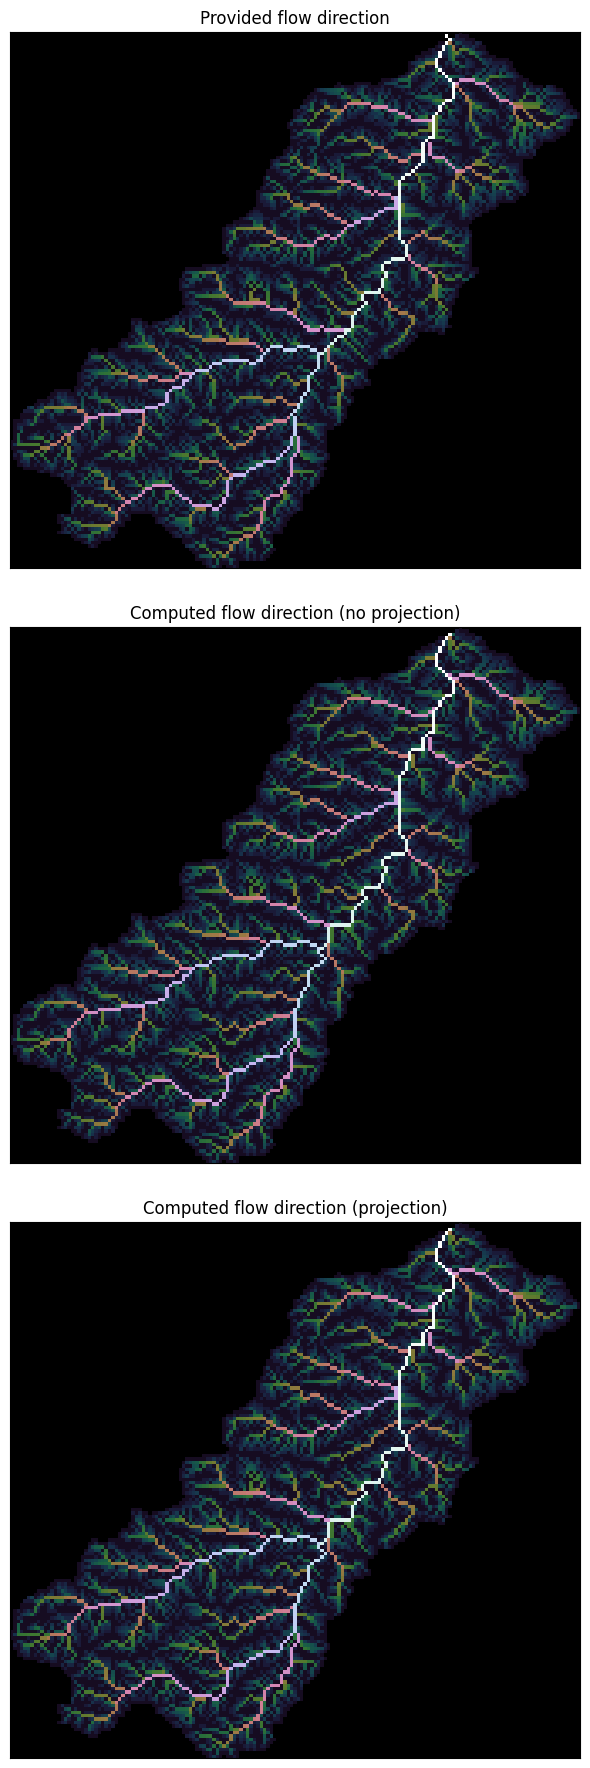

In [16]:
fig, ax = plt.subplots(3, figsize=(6,18))

im0 = ax[0].imshow(acc_ref + 1, extent=grid.extent, zorder=2,
                  cmap='cubehelix', norm=colors.LogNorm(1, acc_ref.max()))

im1 = ax[1].imshow(acc_noproj + 1, extent=grid.extent, zorder=2,
                  cmap='cubehelix', norm=colors.LogNorm(1, acc_noproj.max()))

im2 = ax[2].imshow(acc_proj + 1, extent=grid.extent, zorder=2,
                  cmap='cubehelix', norm=colors.LogNorm(1, acc_proj.max()))

for a in ax:
    a.xaxis.set_ticks([])
    a.yaxis.set_ticks([])

ax[0].set_title('Provided flow direction')
ax[1].set_title('Computed flow direction (no projection)')
ax[2].set_title('Computed flow direction (projection)')
plt.tight_layout()
plt.show()

In [17]:
print(f'Max accumulation (reference):\t\t {acc_ref.max()}')
print(f'Max accumulation (no projection):\t {acc_noproj.max()}')
print(f'Max accumulation (projection):\t\t {acc_proj.max()}')

Max accumulation (reference):		 11422.0
Max accumulation (no projection):	 11418.0
Max accumulation (projection):		 11418.0
